In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import optuna # for hyperparameter tuning
from optuna.samplers import TPESampler

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from imblearn.under_sampling import RandomUnderSampler
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

# Sub-task 3 
### 

In [29]:
df3 = pd.read_csv(r'stroke-data.csv', sep = ',')
df3.info() # bmi has some missing values. So, either: 1- remove them or 2- impute them with mean, median, etc. But, as instructed, all the missing values will be removed.
df3_clean = df3.copy()
df3_clean.dropna(axis = 0, inplace=True)
df3_clean.set_index('id', inplace = True)
df3_clean.drop(['work_type', 'Residence_type'], axis = 1, inplace = True) # No strong relationship with the target column.
print(17 * '----')
print(f'# rows before cleaning: {len(df3)} VS after cleaning: {len(df3_clean)}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
--------------------------------------------------------------------
# rows before cleaning: 5110 VS after cleaning: 4909


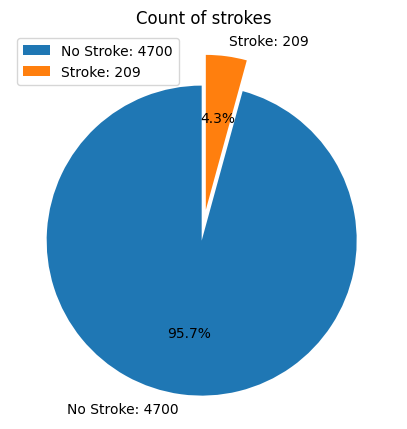

In [30]:
plt.figure(figsize = (5, 7))
plt.pie(df3_clean['stroke'].value_counts(), explode = [0.1, 0.1], 
        labels = [f'No Stroke: {len(df3_clean[df3_clean.stroke == 0])}', f'Stroke: {len(df3_clean[df3_clean.stroke == 1])}'], 
        autopct = '%1.1f%%', startangle = 90)
plt.legend()
plt.title('Count of strokes')
plt.show() # Based on the plot we have an imbalanced dataset

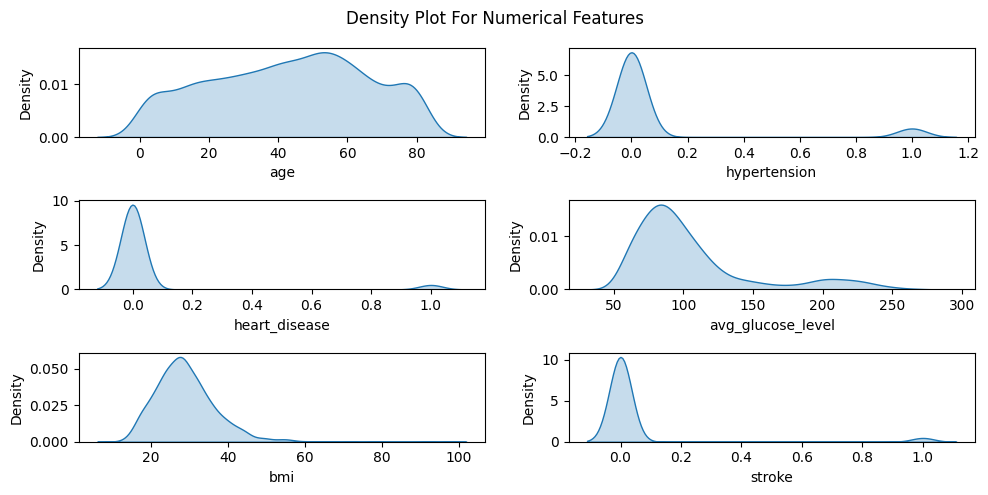

In [31]:
fig, ax = plt.subplots(3, 2, figsize=(10, 5))
ax = ax.flatten()

for idx, column in enumerate(df3_clean.select_dtypes(include=np.number).columns): # [['age', 'avg_glucose_level', 'bmi']]
    sns.kdeplot(df3_clean[column], ax=ax[idx], fill=True)
    ax[idx].set_xlabel(column)
    ax[idx].set_ylabel("Density")

fig.suptitle("Density Plot For Numerical Features")
plt.tight_layout()
plt.show()

In [32]:
# 1- get all categorical columns and convert them to numeric
df3_clean.gender.replace({'Other': 'Male'}, inplace = True)
df3_clean['age_cat'] = pd.cut(df3_clean['age'], bins = [0, 50, 80, float('Inf')], labels = ['young adult', 'middle-aged', 'very old'])
df3_clean.drop('age', axis = 1, inplace = True)
df3_clean = pd.get_dummies(df3_clean, columns = ['gender', 'ever_married', 'smoking_status', 'age_cat'], drop_first = True).astype(np.int16) # int16 is used to reduce excessive computation
df3_clean.columns = df3_clean.columns.str.replace('^_', '', regex = True)
df3_clean = df3_clean[['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 
       'gender_Male', 'ever_married_Yes', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes',
       'age_cat_middle-aged', 'age_cat_very old', 'stroke']] # Reordering columns for better visualization

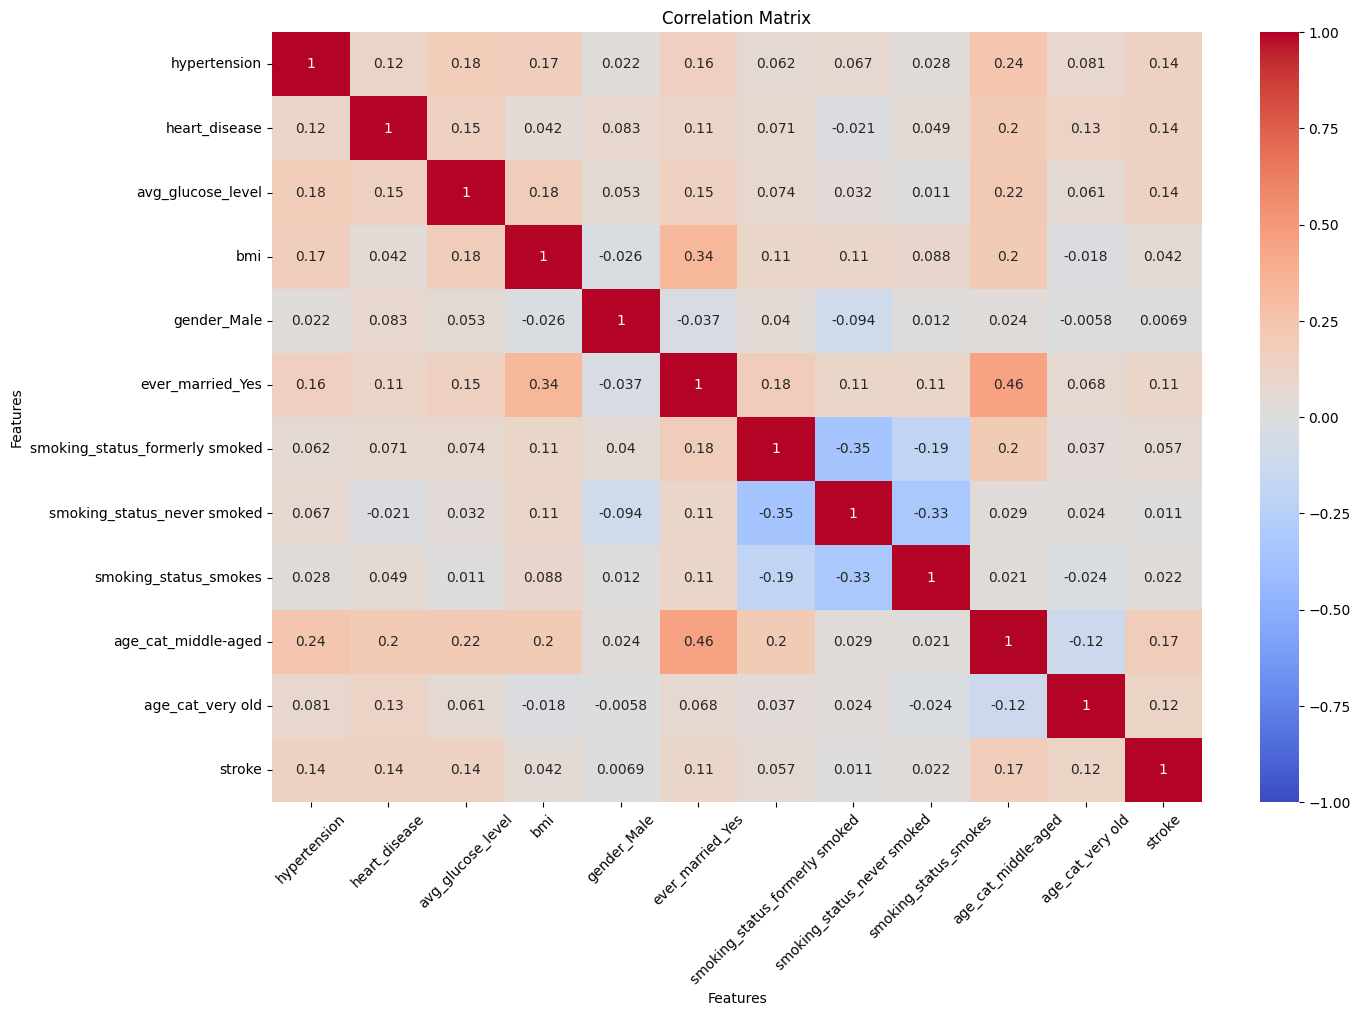

In [33]:
plt.figure(figsize = (15, 10))
corr = (df3_clean.corr())
sns.heatmap(corr, annot = True, cmap = 'coolwarm', vmax = 1, vmin = -1)
plt.title('Correlation Matrix')
plt.xlabel('Features')
plt.xticks(rotation = 45)
plt.ylabel('Features')
plt.show()
# According to the plot, there is no strong correlation between the features and most interesting the bmi and smoking status has very weak correlation with the target column

In [35]:
low_corr = df3_clean.corr()['stroke'][df3_clean.corr()['stroke']< 0.09]
df3_clean.drop(low_corr.index, axis = 1, inplace = True)

In [37]:
df3_final = df3_clean.copy()
X, y = df3_final.drop('stroke', axis = 1), df3_final.stroke
X_train, X_dev, y_train, y_dev = train_test_split(X, y, train_size = 0.8, random_state = 71, stratify = y) # The stratify parameter makes a split so that the proportion of values in the sample produced will be the same as the proportion of values provided by parameter stratify.
X_test, X_val, y_test, y_val = train_test_split(X_dev, y_dev, train_size = 0.5, random_state = 71, stratify = y_dev)

print(f'Train size: {len(X_train)}')
print(f'Test size: {len(X_test)}')
print(f'Val size: {len(X_val)}')
print(f'label0 in train: {len(y_train[y_train == 0])}')
print(f'label1 in train: {len(y_train[y_train == 1])}')
print(f'label0 in test: {len(y_test[y_test == 0])}')
print(f'label1 in test: {len(y_test[y_test == 1])}')
print(f'label0 in val: {len(y_val[y_val == 0])}')
print(f'label1 in val: {len(y_val[y_val == 1])}')
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_val = sc.transform(X_val)

Train size: 3927
Test size: 491
Val size: 491
label0 in train: 3760
label1 in train: 167
label0 in test: 470
label1 in test: 21
label0 in val: 470
label1 in val: 21


In [ ]:
def model(model, X_train, y_train, X_test, y_test):
    '''
    model: model to be trained based on the necessary parameters
    X_train: training data
    y_train: training labels
    X_test: testing data
    y_test: testing labels'''
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'Result of {model}:')
    print(classification_report(y_test, y_pred))
    print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}')
    print(13 * '----')

## 1st trial: 
Train the model with imbalanced data set

In [ ]:
model(MLPClassifier(hidden_layer_sizes = (100, 50, 25),  solver = 'adam', learning_rate = 'adaptive', random_state = 71, max_iter = 1200, ), X_train, y_train, X_val, y_val)
model(SVC(random_state = 71, kernel = 'rbf'), X_train, y_train, X_val, y_val)
model(RandomForestClassifier(random_state = 71, n_estimators = 100, max_depth = 5, min_samples_leaf = 2), X_train, y_train, X_val, y_val)
model(DecisionTreeClassifier(random_state = 71, max_depth = 5, min_samples_leaf = 2), X_train, y_train, X_val, y_val)
model(KNeighborsClassifier(n_neighbors = 15), X_train, y_train, X_val, y_val)
model(LogisticRegression(random_state = 71, solver = 'saga', max_iter = 1000, C = 1), X_train, y_train, X_val, y_val)

Result of MLPClassifier(hidden_layer_sizes=(100, 50, 25), learning_rate='adaptive',
              max_iter=1200, random_state=71):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       470
           1       0.00      0.00      0.00        21

    accuracy                           0.96       491
   macro avg       0.48      0.50      0.49       491
weighted avg       0.92      0.96      0.94       491

Confusion matrix:
[[470   0]
 [ 21   0]]
----------------------------------------------------


c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Result of SVC(random_state=71):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       470
           1       0.00      0.00      0.00        21

    accuracy                           0.96       491
   macro avg       0.48      0.50      0.49       491
weighted avg       0.92      0.96      0.94       491

Confusion matrix:
[[470   0]
 [ 21   0]]
----------------------------------------------------


c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Result of RandomForestClassifier(max_depth=5, min_samples_leaf=2, random_state=71):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       470
           1       0.00      0.00      0.00        21

    accuracy                           0.96       491
   macro avg       0.48      0.50      0.49       491
weighted avg       0.92      0.96      0.94       491

Confusion matrix:
[[470   0]
 [ 21   0]]
----------------------------------------------------
Result of DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, random_state=71):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       470
           1       0.00      0.00      0.00        21

    accuracy                           0.96       491
   macro avg       0.48      0.50      0.49       491
weighted avg       0.92      0.96      0.94       491

Confusion matrix:
[[470   0]
 [ 21   0]]
-------------------------------------------

c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## 2nd trial
Try to modify data set with balancing the classes

In [40]:
df3_final2 = df3_clean.copy()

label1 = df3_final2[df3_final2.stroke == 1].sample(frac = 0.8, random_state = 71) # taking minority label out of the dataset
label0 = df3_final2[df3_final2.stroke == 0].sample(int(len(label1) * 1.5), random_state = 71) # Take 1.5 times the amount of label1 from label0

df3_final2_1 = pd.concat([label1, label0], axis = 0)
df3_finalRemain = df3_final2[~df3_final2.index.isin(df3_final2_1.index)] # taking the rest of the dataset
Xr, yr = df3_finalRemain.drop('stroke', axis = 1), df3_finalRemain.stroke

X, y = df3_final2_1.drop('stroke', axis = 1), df3_final2_1.stroke
X_train, X_dev, y_train, y_dev = train_test_split(X, y, train_size = 0.8, random_state = 71, stratify = y)
X_test, X_val, y_test, y_val = train_test_split(X_dev, y_dev, train_size = 0.2, random_state = 71, stratify = y_dev)

print(f'Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}')
print(8 * '----')
print(f'label(0) in train: {len(y_train[y_train == 0])}, label(1) in train: {len(y_train[y_train == 1])}')
print(8 * '----')
print(f'label(0) in val: {len(y_val[y_val == 0])}, label(1) in val: {len(y_val[y_val == 1])}')
print(8 * '----')
print(f'label(0) in test: {len(y_test[y_test == 0])}, label(1) in test: {len(y_test[y_test == 1])}')

print(8 * '----')
print(f'Remain Size: {len(df3_finalRemain)}')
print(f'Remain label(0): {len(df3_finalRemain[df3_finalRemain.stroke == 0])}')
print(f'Remain label(1): {len(df3_finalRemain[df3_finalRemain.stroke == 1])}')

Train size: 333, Val size: 68, Test size: 16
--------------------------------
label(0) in train: 200, label(1) in train: 133
--------------------------------
label(0) in val: 40, label(1) in val: 28
--------------------------------
label(0) in test: 10, label(1) in test: 6
--------------------------------
Remain Size: 4492
Remain label(0): 4450
Remain label(1): 42


In [41]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)
X_val_sc = sc.transform(X_val)
xr_sc = sc.transform(Xr)

In [ ]:
model(MLPClassifier(hidden_layer_sizes=(10, 50, 25),  solver = 'adam', learning_rate = 'adaptive', random_state = 71, max_iter = 3200), X_train_sc, y_train, X_val_sc, y_val)
model(SVC(random_state = 71, kernel = 'rbf'), X_train_sc, y_train, X_val_sc, y_val)
model(RandomForestClassifier(random_state = 71, n_estimators = 100, max_depth = 5, min_samples_leaf = 2), X_train_sc, y_train, X_val_sc, y_val)
model(DecisionTreeClassifier(random_state = 71, max_depth = 5, min_samples_leaf = 2), X_train_sc, y_train, X_val_sc, y_val)
model(KNeighborsClassifier(n_neighbors = 5), X_train_sc, y_train, X_val_sc, y_val)

Result of MLPClassifier(hidden_layer_sizes=(10, 50, 25), learning_rate='adaptive',
              max_iter=3200, random_state=71):
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        40
           1       0.90      0.64      0.75        28

    accuracy                           0.82        68
   macro avg       0.85      0.80      0.81        68
weighted avg       0.84      0.82      0.82        68

Confusion matrix:
[[38  2]
 [10 18]]
----------------------------------------------------
Result of SVC(random_state=71):
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        40
           1       0.90      0.64      0.75        28

    accuracy                           0.82        68
   macro avg       0.85      0.80      0.81        68
weighted avg       0.84      0.82      0.82        68

Confusion matrix:
[[38  2]
 [10 18]]
----------------------------------------------------
Resu

In [ ]:
def model_compare_sate(model, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test, xr_sc, yr):
    '''
    This function will compare the model performance in each state Train, Val, Test, and remain'''
    model.fit(X_train_sc, y_train)
    y_pred_val = model.predict(X_val_sc)
    y_pred_test = model.predict(X_test_sc)
    y_pred_remain = model.predict(xr_sc)
    print(f'for train with #{len(y_train)}:\n {classification_report(y_train, model.predict(X_train_sc))}\n {confusion_matrix(y_train, model.predict(X_train_sc))}')
    print(15 * '----')
    print(f'for val with #{len(y_val)}:\n {classification_report(y_val, y_pred_val)}\n {confusion_matrix(y_val, y_pred_val)}')
    print(15 * '----')
    print(f'for test with #{len(y_test)}:\n {classification_report(y_test, y_pred_test)}\n {confusion_matrix(y_test, y_pred_test)}')
    print(15 * '----')
    print(f'for remain with #{len(yr)}:\n {classification_report(yr, y_pred_remain)}\n {confusion_matrix(yr, y_pred_remain)}')
    print(15 * '----')
    print('Compare each state:')
    train_pred = f1_score(y_train, model.predict(X_train_sc), average = 'macro')
    val_pred = f1_score(y_val, y_pred_val, average = 'macro')
    test_pred = f1_score(y_test, y_pred_test, average = 'macro')
    test_remain_pred = f1_score(yr, y_pred_remain, average = 'macro')
    print(f'f1 Train score: {train_pred:.4f}\nf1 Val score: {val_pred:.4f}\nf1 Test score: {test_pred:.4f}\nf1 General score: {test_remain_pred:.4f}')

In [44]:
# choose the best model from previous section (SVC, rf, dt, knn)
mlp = MLPClassifier(hidden_layer_sizes=(10, 50, 25),  solver = 'adam', learning_rate = 'adaptive', random_state = 71, max_iter = 1800)
model_compare_sate(mlp, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test, xr_sc, yr)

for train with #333:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       200
           1       0.72      0.65      0.69       133

    accuracy                           0.76       333
   macro avg       0.75      0.74      0.75       333
weighted avg       0.76      0.76      0.76       333

 [[167  33]
 [ 46  87]]
------------------------------------------------------------
for val with #68:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86        40
           1       0.90      0.64      0.75        28

    accuracy                           0.82        68
   macro avg       0.85      0.80      0.81        68
weighted avg       0.84      0.82      0.82        68

 [[38  2]
 [10 18]]
------------------------------------------------------------
for test with #16:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
          

In [45]:
model(XGBClassifier(random_state = 71, max_depth = 5, min_child_weight = 2), X_train_sc, y_train, X_val_sc, y_val)
model(CatBoostClassifier(random_state = 71), X_train_sc, y_train, X_val_sc, y_val)

Result of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        40
           1       0.72      0.75      0.74        28

    accuracy                           0.78        68
   macro avg    

In [46]:
xgb = XGBClassifier(random_state = 71, max_depth = 5, min_child_weight = 2)
catb = CatBoostClassifier(random_state = 71)

model_compare_sate(xgb, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test, xr_sc, yr)
model_compare_sate(catb, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test, xr_sc, yr)

for train with #333:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       200
           1       0.85      0.80      0.82       133

    accuracy                           0.86       333
   macro avg       0.86      0.85      0.86       333
weighted avg       0.86      0.86      0.86       333

 [[182  18]
 [ 27 106]]
------------------------------------------------------------
for val with #68:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81        40
           1       0.72      0.75      0.74        28

    accuracy                           0.78        68
   macro avg       0.77      0.78      0.77        68
weighted avg       0.78      0.78      0.78        68

 [[32  8]
 [ 7 21]]
------------------------------------------------------------
for test with #16:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
          

## 3rd approach 
**Under Sampling**

In [47]:
df3_final = df3_clean.copy()
X, y = df3_final.drop('stroke', axis = 1), df3_final.stroke

rus = RandomUnderSampler(sampling_strategy = 1, random_state = 71)
X_resampled, y_resampled = rus.fit_resample(X, y)

print(f'len X resampled: {len(X_resampled)}')
print(f'len X_resampled[y_resampled == 0]: {len(X_resampled[y_resampled == 0])}')
print(f'len X_resampled[y_resampled == 1]: {len(X_resampled[y_resampled == 1])}')

len X resampled: 418
len X_resampled[y_resampled == 0]: 209
len X_resampled[y_resampled == 1]: 209


In [ ]:
def model_compare_sate_rus(model, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test):
    '''
    This function will compare the model performance in each state Train, Val, and Test
    '''
    model.fit(X_train_sc, y_train)
    y_pred_val = model.predict(X_val_sc)
    y_pred_test = model.predict(X_test_sc)
    print(f'for train with #{len(y_train)}:\n {classification_report(y_train, model.predict(X_train_sc))}\n {confusion_matrix(y_train, model.predict(X_train_sc))}')
    print(15 * '----')
    print(f'for val with #{len(y_val)}:\n {classification_report(y_val, y_pred_val)}\n {confusion_matrix(y_val, y_pred_val)}')
    print(15 * '----')
    print(f'for test with #{len(y_test)}:\n {classification_report(y_test, y_pred_test)}\n {confusion_matrix(y_test, y_pred_test)}')
    print(15 * '----')
    print('Compare each state:')
    train_pred = f1_score(y_train, model.predict(X_train_sc), average = 'macro')
    val_pred = f1_score(y_val, y_pred_val, average = 'macro')
    test_pred = f1_score(y_test, y_pred_test, average = 'macro')
    print(f'f1 Train score: {train_pred:.4f}\nf1 Val score: {val_pred:.4f}\nf1 Test score: {test_pred:.4f}')

In [49]:
X_train_rus, X_dev_rus, y_train_rus, y_dev_rus = train_test_split(X_resampled, y_resampled, train_size = 0.8, random_state = 71)
X_test_rus, X_val_rus, y_test_rus, y_val_rus = train_test_split(X_dev_rus, y_dev_rus, train_size = 0.5, random_state = 71)

print(f'Train size: {len(X_train_rus)}')
print(f'Val size: {len(X_val_rus)}')
print(f'Test size: {len(X_test_rus)}')
print(8 * '----')
print(f'label(0) in train: {len(y_train_rus[y_train_rus == 0])}, label(1) in train: {len(y_train_rus[y_train_rus == 1])}')
print(8 * '----')
print(f'label(0) in val: {len(y_val_rus[y_val_rus == 0])}, label(1) in val: {len(y_val_rus[y_val_rus == 1])}')
print(8 * '----')
print(f'label(0) in test: {len(y_test_rus[y_test_rus == 0])}, label(1) in test: {len(y_test_rus[y_test_rus == 1])}')

sc_rus = StandardScaler()
X_train_rus_sc = sc_rus.fit_transform(X_train_rus)
X_test_rus_sc = sc_rus.transform(X_test_rus)
X_val_rus_sc = sc_rus.transform(X_val_rus)

Train size: 334
Val size: 42
Test size: 42
--------------------------------
label(0) in train: 168, label(1) in train: 166
--------------------------------
label(0) in val: 18, label(1) in val: 24
--------------------------------
label(0) in test: 23, label(1) in test: 19


In [50]:
svc_pred = model(SVC(random_state=71, kernel = 'rbf'), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)
mlp_pred = model(MLPClassifier(hidden_layer_sizes=(10, 50, 25),  solver = 'adam', learning_rate = 'adaptive', random_state = 71, max_iter = 3200), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)
rf_pred = model(RandomForestClassifier(random_state=71), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)
knn_pred = model(KNeighborsClassifier(n_neighbors = 5), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)
xgb_pred = model(XGBClassifier(n_estimators = 100, learning_rate = 0.1, alpha = 10, random_state = 71, max_depth = 5), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)
catboost_pred = model(CatBoostClassifier(random_state = 71), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)
lightgbm_pred = model(LGBMClassifier(random_state = 71, lambda_l1 = 0.1), X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus)

Result of SVC(random_state=71):
              precision    recall  f1-score   support

           0       1.00      0.56      0.71        18
           1       0.75      1.00      0.86        24

    accuracy                           0.81        42
   macro avg       0.88      0.78      0.79        42
weighted avg       0.86      0.81      0.80        42

Confusion matrix:
[[10  8]
 [ 0 24]]
----------------------------------------------------
Result of MLPClassifier(hidden_layer_sizes=(10, 50, 25), learning_rate='adaptive',
              max_iter=3200, random_state=71):
              precision    recall  f1-score   support

           0       0.71      0.56      0.62        18
           1       0.71      0.83      0.77        24

    accuracy                           0.71        42
   macro avg       0.71      0.69      0.70        42
weighted avg       0.71      0.71      0.71        42

Confusion matrix:
[[10  8]
 [ 4 20]]
----------------------------------------------------
Resu

In [51]:
svc_rus = SVC(random_state=71, kernel = 'rbf')
xgb_rus = XGBClassifier(n_estimators = 100, learning_rate = 0.1, alpha = 10, random_state = 71, max_depth = 5)
catboost_rus = CatBoostClassifier(random_state = 71)
lightgbm_rus = LGBMClassifier(random_state = 71, lambda_l1 = 0.1)

model_compare_sate_rus(svc_rus, X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, X_test_rus_sc, y_test_rus)
model_compare_sate_rus(xgb_rus, X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, X_test_rus_sc, y_test_rus)
model_compare_sate_rus(catboost_rus, X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, X_test_rus_sc, y_test_rus)
model_compare_sate_rus(lightgbm_rus, X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, X_test_rus_sc, y_test_rus)

for train with #334:
               precision    recall  f1-score   support

           0       0.86      0.58      0.70       168
           1       0.68      0.90      0.78       166

    accuracy                           0.74       334
   macro avg       0.77      0.74      0.74       334
weighted avg       0.77      0.74      0.74       334

 [[ 98  70]
 [ 16 150]]
------------------------------------------------------------
for val with #42:
               precision    recall  f1-score   support

           0       1.00      0.56      0.71        18
           1       0.75      1.00      0.86        24

    accuracy                           0.81        42
   macro avg       0.88      0.78      0.79        42
weighted avg       0.86      0.81      0.80        42

 [[10  8]
 [ 0 24]]
------------------------------------------------------------
for test with #42:
               precision    recall  f1-score   support

           0       0.81      0.57      0.67        23
          

## Hyper parameter tuning

In [ ]:
def objective(trial, model_class, X_train_sc, y_train, X_val_sc, y_val):
    '''
    Define a a function to tune hyperparameters of specific models
    '''
    if model_class == SVC:
        params = {
        'C': trial.suggest_float('C', 0.1, 10, log=True),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'probability': True
        }
        model = model_class(**params, random_state = 92)

    elif model_class == RandomForestClassifier:
        params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
        }
        model = model_class(**params, random_state = 92)

    elif model_class == KNeighborsClassifier:
        params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 2)  # 1 for manhattan, 2 for euclidean
        }
        model = model_class(**params)

    elif model_class == MLPClassifier:
        params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(10,), (10, 50), (10, 50, 25)]),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'invscaling', 'adaptive']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
        }
        model = model_class(**params, solver = 'adam', max_iter = 3200, random_state = 92)

    elif model_class == LGBMClassifier:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 600, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log = True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0, log = True),
            'lambda_l1': trial.suggest_float('lambda_l1', 0.01, 1.0, log = True)
        }
        model = model_class(**params, min_child_samples = 114, force_col_wise = True, 
                            num_leaves = 183, random_state = 92)
    elif model_class == XGBClassifier:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 600, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log = True),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0, log = True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0, log  =True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
        }
        model = model_class(**params, random_state = 92)

    elif model_class == CatBoostClassifier:
        params = {
            'iterations': trial.suggest_int('iterations', 2000, 4000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log = True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log = True)
        }
        model = model_class(**params, random_state = 92, subsample = 0.8, verbose = 0)

    pipeline = Pipeline([
        ('model', model)
    ])

    pipeline.fit(X_train_sc, y_train)
    y_pred = pipeline.predict(X_val_sc)
    return f1_score(y_val, y_pred)


def tune_hyperparameters(X_train_sc, y_train, X_val_sc, y_val, model_class, n_trials = 5):
    study = optuna.create_study(direction='maximize', sampler = TPESampler())
    study.optimize(lambda trial: objective(trial, model_class, X_train_sc, y_train, X_val_sc, y_val),
                   n_trials=n_trials)
    return study.best_params


def tune_voting_classifier(X_train_sc, y_train, X_val_sc, y_val,
                           svc_params, rf_params, knn_params, mlp_params, xgb_params, lgbm_params, catboost_params, n_trials = 5):
    def objective(trial):
        weight_svc = trial.suggest_int('weight_svc', 1, 10)
        weight_rf = trial.suggest_int('weight_rf', 1, 10)
        weight_knn = trial.suggest_int('weight_knn', 1, 10)
        weight_mlp = trial.suggest_int('weight_mlp', 1, 10)
        weight_xgb = trial.suggest_int('weight_xgb', 1, 10)
        weight_lgbm = trial.suggest_int('weight_lgbm', 1, 10)
        weight_catboost = trial.suggest_int('weight_catboost', 1, 10)

        svc_model = SVC(**svc_params, probability = True, random_state = 92)
        rf_model = RandomForestClassifier(**rf_params, random_state = 92)
        knn_model = KNeighborsClassifier(**knn_params)
        mlp_model = MLPClassifier(**mlp_params, random_state = 92)
        xgb_model = XGBClassifier(**xgb_params, random_state = 92)
        lgbm_model = LGBMClassifier(**lgbm_params, random_state = 92)
        catboost_model = CatBoostClassifier(**catboost_params, random_state = 92, verbose = 0)

        voting_clf = VotingClassifier(
            estimators = [
                ('svc', svc_model),
                ('rf', rf_model),
                ('knn', knn_model),
                ('mlp', mlp_model),
                ('xgb', xgb_model),
                ('lgbm', lgbm_model),
                ('catboost', catboost_model)
            ],
            weights = [weight_svc, weight_rf, weight_knn, weight_mlp, weight_xgb, weight_lgbm, weight_catboost],
            voting = 'soft'
        )

        pipeline = Pipeline([
            ('model', voting_clf)
        ])

        pipeline.fit(X_train_sc, y_train)
        y_pred = pipeline.predict(X_val_sc)
        return f1_score(y_val, y_pred)

    study = optuna.create_study(direction = 'maximize', sampler = TPESampler())
    study.optimize(objective, n_trials = n_trials)
    return study.best_params

In [53]:
best_svc_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, SVC, n_trials = 2)
best_rf_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, RandomForestClassifier, n_trials = 2)
best_knn_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, KNeighborsClassifier, n_trials = 2)
best_mlp_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, MLPClassifier, n_trials = 2)
best_xgb_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, XGBClassifier, n_trials = 2)
best_lgbm_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, LGBMClassifier, n_trials = 2)
best_catboost_params = tune_hyperparameters(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, CatBoostClassifier, n_trials = 2)
best_voting_params = tune_voting_classifier(X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, best_svc_params, best_rf_params, best_knn_params, best_mlp_params, 
                                            best_xgb_params, best_lgbm_params, best_catboost_params, n_trials = 2)
print('Final hyperparameters:')
print(f'best_svc_params: {best_svc_params}\n {10 * "-"}')
print(f'best_rf_params: {best_rf_params}\n {10 * "-"}')
print(f'best_knn_params: {best_knn_params}\n {10 * "-"}')
print(f'best_mlp_params: {best_mlp_params}\n {10 * "-"}')
print(f'best_xgb_params: {best_xgb_params}\n {10 * "-"}')
print(f'best_lgbm_params: {best_lgbm_params}\n {10 * "-"}')
print(f'best_catboost_params: {best_catboost_params}\n {10 * "-"}')
print(f'best_voting_params: {best_voting_params}\n {10 * "-"}')

[I 2025-05-03 19:41:34,289] A new study created in memory with name: no-name-c986e195-ce1b-4a6e-9247-f00754185bd0
[I 2025-05-03 19:41:34,340] Trial 0 finished with value: 0.6829268292682927 and parameters: {'C': 0.8418768807091016, 'kernel': 'poly', 'gamma': 'auto'}. Best is trial 0 with value: 0.6829268292682927.
[I 2025-05-03 19:41:34,396] Trial 1 finished with value: 0.6976744186046512 and parameters: {'C': 1.7746288446307452, 'kernel': 'poly', 'gamma': 'auto'}. Best is trial 1 with value: 0.6976744186046512.
[I 2025-05-03 19:41:34,400] A new study created in memory with name: no-name-802e1819-f957-4217-9ada-35af949327ce
[I 2025-05-03 19:41:34,809] Trial 0 finished with value: 0.8076923076923077 and parameters: {'n_estimators': 85, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8076923076923077.
[I 2025-05-03 19:41:35,362] Trial 1 finished with value: 0.7843137254901961 and parameters: {'n_estimators': 142, 'max_depth': 9, 'min_samples_

[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
[LightGBM] [Info] Number of positive: 166, number of negative: 168
[LightGBM] [Info] Total Bins 83
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497006 -> initscore=-0.011976
[LightGBM] [Info] Start training from score -0.011976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[I 2025-05-03 19:41:42,193] Trial 1 finished with value: 0.8148148148148148 and parameters: {'n_estimators': 764, 'learning_rate': 0.01817465486339908, 'max_depth': 8, 'reg_alpha': 0.07916530619267391, 'lambda_l1': 0.021188150577529943}. Best is trial 0 with value: 0.8148148148148148.
[I 2025-05-03 19:41:42,197] A new study created in memory with name: no-name-14f58bc6-5bdd-495f-a8b9-1bbbe65bb9bf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-05-03 19:41:58,939] Trial 0 finished with value: 0.723404255319149 and parameters: {'iterations': 3522, 'learning_rate': 0.05022414502951608, 'depth': 4, 'l2_leaf_reg': 1.0099196214246808}. Best is trial 0 with value: 0.723404255319149.
[I 2025-05-03 19:42:27,636] Trial 1 finished with value: 0.75 and parameters: {'iterations': 2331, 'learning_rate': 0.04372307515900353, 'depth': 9, 'l2_leaf_reg': 3.4254505288690016}. Best is trial 1 with value: 0.75.
[I 2025-05-03 19:42:27,641] A new study created in memory with name: no-name-fdac8f29-881b-4a82-bd62-aaf649cb4199
c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


...

[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074


c:\Users\fishe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
[LightGBM] [Info] Number of positive: 166, number of negative: 168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 95
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497006 -> initscore=-0.011976
[LightGBM] [Info] Start training from score -0.011976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-05-03 19:43:34,909] Trial 1 finished with value: 0.7755102040816326 and parameters: {'weight_svc': 6, 'weight_rf': 2, 'weight_knn': 3, 'weight_mlp': 3, 'weight_xgb': 3, 'weight_lgbm': 1, 'weight_catboost': 10}. Best is trial 0 with value: 0.7755102040816326.


[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
Final hyperparameters:
best_svc_params: {'C': 1.7746288446307452, 'kernel': 'poly', 'gamma': 'auto'}
 ----------
best_rf_params: {'n_estimators': 85, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3}
 ----------
best_knn_params: {'n_neighbors': 12, 'weights': 'distance', 'p': 2}
 ----------
best_mlp_params: {'hidden_layer_sizes': (10,), 'learning_rate': 'adaptive', 'alpha': 0.0007139550758870535}
 ----------
best_xgb_params: {'n_estimators': 878, 'learning_rate': 0.04061876514835898, 'reg_alpha': 0.5654867080940317, 'reg_lambda': 0.13313540813791877, 'max_depth': 9, 'min_child_weight': 2}
 ----------
best_lgbm_params: {'n_estimators': 617, 'learning_rate': 0.014753706135576522, 'max_depth': 5, 'reg_alpha': 0.022342264551631186, 'lambda_l1': 0.043697319908645074}
 ----------
best_catboost_params: {'iterations': 2331, 'lear

In [54]:
ensembled_model = VotingClassifier(
    estimators = [
        ('svc', SVC(**best_svc_params, probability = True, random_state = 92)),
        ('rf', RandomForestClassifier(**best_rf_params, random_state = 92)),
        ('knn', KNeighborsClassifier(**best_knn_params)),
        ('mlp', MLPClassifier(**best_mlp_params, random_state = 92, max_iter = 3200)),
        ('xgb', XGBClassifier(**best_xgb_params, random_state = 92)),
        ('lgbm', LGBMClassifier(**best_lgbm_params, random_state = 92)),
        ('catboost', CatBoostClassifier(**best_catboost_params, random_state = 92, verbose = 0))
    ],
    weights = [best_voting_params['weight_svc'], best_voting_params['weight_rf'], best_voting_params['weight_knn'], best_voting_params['weight_mlp'],
               best_voting_params['weight_xgb'], best_voting_params['weight_lgbm'], best_voting_params['weight_catboost']],
    voting = 'soft'
)
model_compare_sate_rus(ensembled_model, X_train_rus_sc, y_train_rus, X_val_rus_sc, y_val_rus, X_test_rus_sc, y_test_rus)

[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
[LightGBM] [Warning] lambda_l1 is set=0.043697319908645074, reg_alpha=0.022342264551631186 will be ignored. Current value: lambda_l1=0.043697319908645074
[LightGBM] [Info] Number of positive: 166, number of negative: 168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 95
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497006 -> initscore=-0.011976
[LightGBM] [Info] Start training from score -0.011976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

## Summary
In this task, the provided dataset focuses on stroke prediction, containing 12 features, including an id column and the target variable, with a total of 5,110 instances.
Initially, the data underwent cleaning and preprocessing as outlined in [1], followed by EDA analysis to gain insights. Correlation analysis revealed weak relationships between some features and the target variable, leading to the removal of low-correlation features and that create dimension reduction.
After processing, three approaches were implemented:
- Training models on the imbalanced dataset – To mitigate class imbalance, **stratification was applied**, ensuring each subset maintained approximately the same proportion of each target class as the full dataset [2]. The result shows weak result for class 1 which is important, patient got stroke, because false prediction for this class is costly. In order to reduce this problem other approaches were tried.
- Balancing the dataset via **selective sampling** – Two sets were created: the first consisted of most of the minority class sampled randomly, while the second included a larger proportion of the majority class, aiming to reduce imbalance effect [3]. This approach significantly improved the classification of both classes (particularly the minority class labeled as 1). However, overfitting persisted across both methods.
- Under sampling to preserve the minority class – The final approach applied under sampling [3] to maintain minority class representation. While this method showed performance improvements, overfitting remained an issue, warranting further analysis.
To address overfitting, hyperparameter tuning and ensemble modeling were explored, drawing from techniques proposed in [4][5] with some modifications tailored to this problem. However, further studies required to address this problem. Based on the nature of this dataset, identifying minority class is far more important than falsely label healthy individual people(cost less). For the 2nd and 3rd approach there is a huge improvement in identifying minority class.



---------
### Refrences
1- Age- and Gender-Specific Prevalence of Risk Factors in Patients with First-Ever Ischemic Stroke in China [web page](https://doi.org/10.1155/2012/136398)

2- Stratify  [web page](https://scikit-learn.org/stable/modules/cross_validation.html#stratification)

3- Learning from Imbalanced Data [web page](https://ieeexplore.ieee.org/document/5128907)

4- From Classroom to Kaggle Competitions: Mastering Regression for Flood Prediction [web page](https://medium.com/@samiraalipour/from-classroom-to-kaggle-competitions-mastering-regression-for-flood-prediction-cd9eb00837a6)

5- Optuna vs GridSearchCV vs RandomSearchCV— Hyperparameter Tuning Techniques [web page](https://medium.com/@abhishekjainindore24/optuna-vs-gridsearchcv-vs-randomsearchcv-hyperparameter-tuning-techniques-ea8e2ada28d0#:~:text=Unlike%20traditional%20methods%20like%20Grid,more%20likely%20to%20improve%20performance.)